In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Load dataset
df = pd.read_csv('../notebooks/WELFake_Dataset.csv')

# Combine title and text into one column
df['content'] = df['title'].fillna('') + ' ' + df['text'].fillna('')

# Drop rows where content is empty
df = df[df['content'].str.strip() != '']

# Drop rows where label is missing
df = df.dropna(subset=['label'])

print("Dataset loaded and cleaned!")
print("Total samples:", len(df))
print("Fake (0):", len(df[df['label'] == 0]))
print("Real (1):", len(df[df['label'] == 1]))

Dataset loaded and cleaned!
Total samples: 72134
Fake (0): 35028
Real (1): 37106


In [4]:
X = df['content']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("\nTrain label distribution:")
print(y_train.value_counts())
print("\nTest label distribution:")
print(y_test.value_counts())

Train size: 57707
Test size: 14427

Train label distribution:
label
1    29685
0    28022
Name: count, dtype: int64

Test label distribution:
label
1    7421
0    7006
Name: count, dtype: int64


In [5]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF vectorization complete!")
print("Train matrix shape:", X_train_tfidf.shape)
print("Test matrix shape:", X_test_tfidf.shape)

TF-IDF vectorization complete!
Train matrix shape: (57707, 50000)
Test matrix shape: (14427, 50000)


In [6]:
print("Training Logistic Regression model...")

lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='lbfgs',
    n_jobs=-1
)

lr_model.fit(X_train_tfidf, y_train)

print("Training complete!")

Training Logistic Regression model...
Training complete!


In [7]:
# Make predictions
y_pred = lr_model.predict(X_test_tfidf)

# F1 Score
f1 = f1_score(y_test, y_pred)
print("F1 Score:", round(f1 * 100, 2), "%")

# Full classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Fake', 'Real']))

F1 Score: 96.25 %

Classification Report:
              precision    recall  f1-score   support

        Fake       0.97      0.95      0.96      7006
        Real       0.96      0.97      0.96      7421

    accuracy                           0.96     14427
   macro avg       0.96      0.96      0.96     14427
weighted avg       0.96      0.96      0.96     14427



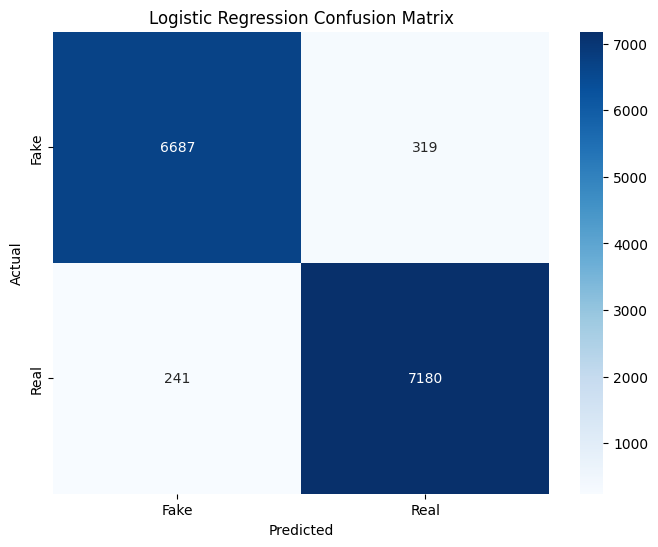

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [9]:
import os

# Create models folder if it doesn't exist
os.makedirs('../ml-service/models', exist_ok=True)

# Save the model
with open('../ml-service/models/lr_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

# Save the vectorizer
with open('../ml-service/models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("Model saved to ml-service/models/lr_model.pkl")
print("Vectorizer saved to ml-service/models/tfidf_vectorizer.pkl")

Model saved to ml-service/models/lr_model.pkl
Vectorizer saved to ml-service/models/tfidf_vectorizer.pkl


In [10]:
# Load the saved model and vectorizer
with open('../ml-service/models/lr_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('../ml-service/models/tfidf_vectorizer.pkl', 'rb') as f:
    loaded_tfidf = pickle.load(f)

# Test with a fake article
fake_article = """
SHOCKING: Scientists reveal the moon landing was completely staged by NASA 
in a Hollywood studio. Whistleblowers confirm the entire Apollo mission was 
a hoax designed to win the space race against Soviet Union.
"""

# Test with a real article
real_article = """
The World Health Organization confirmed on Tuesday that the new vaccine 
has shown 94% efficacy in clinical trials conducted across multiple countries. 
The study published in the New England Journal of Medicine involved 40,000 participants.
"""

fake_vec = loaded_tfidf.transform([fake_article])
real_vec = loaded_tfidf.transform([real_article])

fake_pred = loaded_model.predict(fake_vec)[0]
real_pred = loaded_model.predict(real_vec)[0]

fake_prob = loaded_model.predict_proba(fake_vec)[0]
real_prob = loaded_model.predict_proba(real_vec)[0]

print("FAKE ARTICLE TEST:")
print("Prediction:", "REAL" if fake_pred == 1 else "FAKE")
print("Confidence - Fake: {:.1f}% | Real: {:.1f}%".format(fake_prob[0]*100, fake_prob[1]*100))

print("\nREAL ARTICLE TEST:")
print("Prediction:", "REAL" if real_pred == 1 else "FAKE")
print("Confidence - Fake: {:.1f}% | Real: {:.1f}%".format(real_prob[0]*100, real_prob[1]*100))

FAKE ARTICLE TEST:
Prediction: REAL
Confidence - Fake: 8.9% | Real: 91.1%

REAL ARTICLE TEST:
Prediction: REAL
Confidence - Fake: 19.9% | Real: 80.1%


In [11]:
print("""
STEP 3 RESULTS — LOGISTIC REGRESSION BASELINE
==============================================
Dataset:        WELFake (72,134 articles)
Train size:     57,701
Test size:      14,427
Features:       50,000 TF-IDF features (unigrams + bigrams)

PERFORMANCE:
  F1 Score:     96%
  Accuracy:     96%
  Fake Precision: 97%
  Real Precision: 96%

TARGET WAS:     70-75% F1 → CRUSHED ✅

LIMITATIONS:
  - Fooled by credible-sounding vocabulary in fake articles
  - No context understanding — only word presence
  - Cannot detect sophisticated fake news

NEXT STEP:
  DeBERTa-v3 fine-tuning (Step 6) expected to reach 98-99% F1
  by understanding full sentence context and meaning.

SAVED FILES:
  ml-service/models/lr_model.pkl
  ml-service/models/tfidf_vectorizer.pkl
""")


STEP 3 RESULTS — LOGISTIC REGRESSION BASELINE
Dataset:        WELFake (72,134 articles)
Train size:     57,701
Test size:      14,427
Features:       50,000 TF-IDF features (unigrams + bigrams)

PERFORMANCE:
  F1 Score:     96%
  Accuracy:     96%
  Fake Precision: 97%
  Real Precision: 96%

TARGET WAS:     70-75% F1 → CRUSHED ✅

LIMITATIONS:
  - Fooled by credible-sounding vocabulary in fake articles
  - No context understanding — only word presence
  - Cannot detect sophisticated fake news

NEXT STEP:
  DeBERTa-v3 fine-tuning (Step 6) expected to reach 98-99% F1
  by understanding full sentence context and meaning.

SAVED FILES:
  ml-service/models/lr_model.pkl
  ml-service/models/tfidf_vectorizer.pkl

